In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import seaborn as sns


In [13]:
# Create sequences for a single file without night separation
def create_sequences(data, timesteps=18):
    X, y = [], []

    for i in range(len(data) - timesteps):
        X.append(data[i:i + timesteps, :-1])  # HRV features (RMSSD, LF, HF)
        y.append(data[i + timesteps, -1])  # Corresponding glucose value

    return np.array(X), np.array(y)

In [14]:

# List of DataFrames for each night
night_dfs = [night1, night2, night3, night4, night5, night6, night7, night8, night9, night10, night11, night12, night13, night14, night15, night16, night17, night18, night19, night20, night21, night22, night23,night24, night25, night26,night27,night28,night29,night30,night31,night32, night33,night34,night35,night36,night37,night38,night39,night40,night41,night42,night43,night44,night45]

# Initialize empty lists to store sequences
X_all, y_all = [], []

# Loop through each night and create sequences
for night_df in night_dfs:
    # Convert DataFrame to NumPy
    data = night_df[['rmssd', 'lf', 'hf', 'Infrared to Red Signal Ratio', 'glucose']].values

    # Generate sequences for the night
    X_night, y_night = create_sequences(data, timesteps=18)

    # Append to list
    X_all.append(X_night)
    y_all.append(y_night)

# Combine all sequences into one NumPy array
X_combined = np.concatenate(X_all, axis=0)
y_combined = np.concatenate(y_all, axis=0)

print("Final Combined X shape:", X_combined.shape)
print("Final Combined y shape:", y_combined.shape)


Final Combined X shape: (3125, 18, 4)
Final Combined y shape: (3125,)


In [15]:
print(np.mean(y_combined, axis=0))

4.8716159999999995


In [16]:
def remove_outliers_zscore(data, threshold=3.0):
    """Removes outliers using the Z-score method."""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    z_scores = (data - mean) / std
    return np.where(np.abs(z_scores) > threshold, mean, data)  # Replace outliers with the mean

scaler = StandardScaler()
n_samples, timesteps, n_features = X_combined.shape
X_reshaped = X_combined.reshape(-1, n_features)  # Flatten to 2D for scaling

# Remove outliers using Z-score method before scaling
X_reshaped = remove_outliers_zscore(X_reshaped)

X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(n_samples, timesteps, n_features)

y_scaler = StandardScaler()
y_reshaped = y_combined.reshape(-1, 1)

# Remove outliers using Z-score method before scaling
y_reshaped = remove_outliers_zscore(y_reshaped)

y_scaled = y_scaler.fit_transform(y_reshaped)
y_scaled = y_scaled.flatten()


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


In [18]:
def create_gru_model(input_timesteps=18, input_features=4):
    model = Sequential([
        GRU(64, input_shape=(input_timesteps, input_features), return_sequences=False),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    model.compile(loss="mse", optimizer="adam")
    return model

# Create model
model = create_gru_model(input_timesteps=18, input_features=4)

# Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=8, shuffle=True)

# Extract training & validation metrics
train_loss_per_epoch = history.history['loss']
val_loss_per_epoch = history.history['val_loss']

# Print loss & RMSE for each epoch
for epoch, (train_loss, val_loss) in enumerate(zip(train_loss_per_epoch, val_loss_per_epoch)):
    print(f'Epoch {epoch + 1}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}')


/Users/tomliu/Library/Python/3.11/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.9488 - val_loss: 0.9206
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9206 - val_loss: 0.9081
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.9100 - val_loss: 0.8658
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9345 - val_loss: 0.9244
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8407 - val_loss: 0.8598
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7816 - val_loss: 0.7959
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7254 - val_loss: 0.7943
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7504 - val_loss: 0.7821
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7426 - val_loss: 0.7478
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7262 - val_loss: 0.7304
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6474 - val_loss: 0.7093
Epoch 12/100
313/313 ━━━━━━━━━━━━━━━━━━━

In [27]:
import time
sample_input = np.random.rand(8, 18, 4).astype(np.float32)  # Adjusted for batch_size=8

start_time = time.time()
_ = model.predict(sample_input)
end_time = time.time()

inference_time = (end_time - start_time)/(sample_input.shape[0]) * 1000  # Convert to milliseconds
print(f"Inference Time: {inference_time:.3f} ms per sample")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Inference Time: 66.573 ms per sample


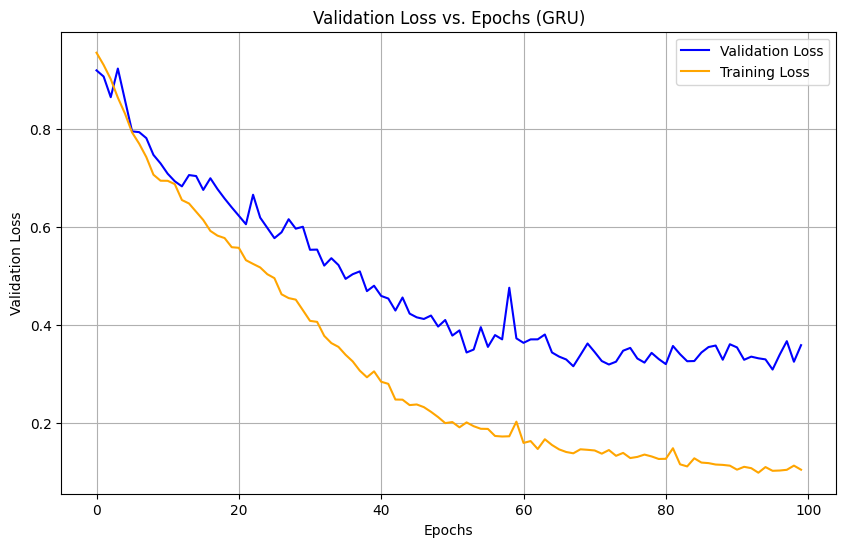

In [19]:

# Step 5: Plot Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.plot(history.history['loss'], label='Training Loss', color='orange')

plt.title('Validation Loss vs. Epochs (GRU)')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [20]:
def reset_states(model: tf.keras.Model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.LSTM):
            layer.reset_states()

reset_states(model)

# Step 1: Predict on X_test
y_pred_standardized = model.predict(X_test)

# Step 2: Ensure the data is 2D before inverse transforming
y_pred_standardized = y_pred_standardized.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)  # Ensure y_test is also 2D if needed

# Step 2: Unstandardize predictions
y_pred = y_scaler.inverse_transform(y_pred_standardized)

# Step 3: Unstandardize actual y_test
y_test_unstandardized = y_scaler.inverse_transform(y_test)

# Step 4: Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_unstandardized, y_pred))
print(f'RMSE: {rmse}')
mse=mean_squared_error(y_test_unstandardized, y_pred)
print(f'MSE:  {mse}')

mae= mean_absolute_error(y_test_unstandardized, y_pred)
print(f'MAE:  {mae}')

r2 = r2_score(y_test_unstandardized, y_pred)
print(f'R^2 : {r2}')


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
RMSE: 0.3944976753225923
MSE:  0.15562841583492942
MAE:  0.27110046551694333
R^2 : 0.6401291884666778


In [ ]:
df_combined = pd.concat(night_dfs, ignore_index=True)
print(df_combined)


(<module 'matplotlib.pyplot' from '/Users/tomliu/Library/Python/3.11/lib/python/site-packages/matplotlib/pyplot.py'>,
 [602, 15, 0, 8, 0])

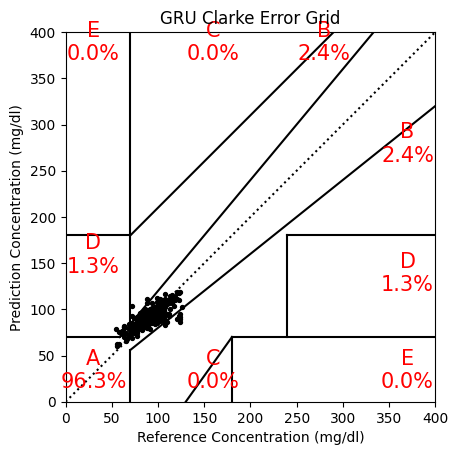

In [22]:

def clarke_error_grid(ref_values, pred_values, title_string):
    ref_values = np.array(ref_values) * 18
    pred_values = np.array(pred_values) * 18
    total_points = len(ref_values)  # Total number of points

    # Set up plot
    plt.scatter(ref_values, pred_values, marker='o', color='black', s=8)
    plt.title(title_string + " Clarke Error Grid")
    plt.xlabel("Reference Concentration (mg/dl)")
    plt.ylabel("Prediction Concentration (mg/dl)")
    plt.xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.gca().set_facecolor('white')

    # Set axes lengths
    plt.gca().set_xlim([0, 400])
    plt.gca().set_ylim([0, 400])
    plt.gca().set_aspect((400)/(400))

    # Plot zone lines
    plt.plot([0, 400], [0, 400], ':', c='black')                      # Theoretical 45 regression line
    plt.plot([0, 175/3], [70, 70], '-', c='black')
    plt.plot([175/3, 400/1.2], [70, 400], '-', c='black')           
    plt.plot([70, 70], [84, 400],'-', c='black')
    plt.plot([0, 70], [180, 180], '-', c='black')
    plt.plot([70, 290], [180, 400], '-', c='black')
    plt.plot([70, 70], [0, 56], '-', c='black')                    
    plt.plot([70, 400], [56, 320],'-', c='black')
    plt.plot([180, 180], [0, 70], '-', c='black')
    plt.plot([180, 400], [70, 70], '-', c='black')
    plt.plot([240, 240], [70, 180],'-', c='black')
    plt.plot([240, 400], [180, 180], '-', c='black')
    plt.plot([130, 180], [0, 70], '-', c='black')

    # Statistics from the data
    zone = [0] * 5  # [A, B, C, D, E]
    for i in range(len(ref_values)):
        if (ref_values[i] <= 70 and pred_values[i] <= 70) or (pred_values[i] <= 1.2 * ref_values[i] and pred_values[i] >= 0.8 * ref_values[i]):
            zone[0] += 1  # Zone A

        elif (ref_values[i] >= 180 and pred_values[i] <= 70) or (ref_values[i] <= 70 and pred_values[i] >= 180):
            zone[4] += 1  # Zone E

        elif ((ref_values[i] >= 70 and ref_values[i] <= 290) and pred_values[i] >= ref_values[i] + 110) or ((ref_values[i] >= 130 and ref_values[i] <= 180) and (pred_values[i] <= (7/5) * ref_values[i] - 182)):
            zone[2] += 1  # Zone C

        elif (ref_values[i] >= 240 and (pred_values[i] >= 70 and pred_values[i] <= 180)) or (ref_values[i] <= 175/3 and pred_values[i] <= 180 and pred_values[i] >= 70) or ((ref_values[i] >= 175/3 and ref_values[i] <= 70) and pred_values[i] >= (6/5) * ref_values[i]):
            zone[3] += 1  # Zone D

        else:
            zone[1] += 1  # Zone B

    # Convert counts to percentages
    zone_percentages = [100 * (z / total_points) for z in zone]

    # Add zone labels with percentage in red
    plt.text(30, 15, f"A\n{zone_percentages[0]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 260, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(280, 370, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 370, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 15, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 140, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 120, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 370, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 15, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')

    return plt, zone

# Example usage
clarke_error_grid(y_test_unstandardized, y_pred, "GRU")


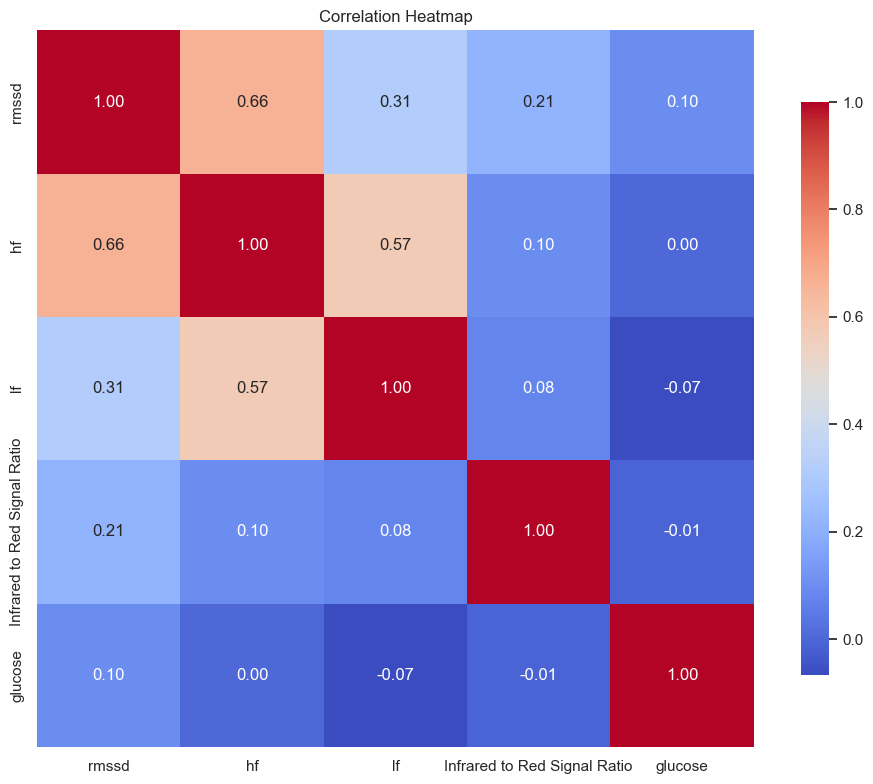

In [23]:
# Select the relevant columns
correlation_columns = ['rmssd', 'hf', 'lf', 'Infrared to Red Signal Ratio', 'glucose']
correlation_matrix = df_combined[correlation_columns].corr()
# Set the style of seaborn
sns.set(style="white")

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
